In [1]:
import scanpy as sc
import pandas as pd
import anndata as ad

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pandas.api.types import CategoricalDtype

## Load Data

In [2]:
adata = ad.read_h5ad("./data/adata_cleaned.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 2092 × 14046
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id_snp', 'hashedDrops_Best', 'hashedDrops_Second', 'hashedDrops_LogFC', 'hashedDrops_LogFC2', 'hashedDrops_Doublet', 'hashedDrops_Confident', 'hashedDrops_classification', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Donor_ID_HTOdemux_localSNP', 'Timepoint', 'tetramer_batch', 'dosage', 'HTO_SNP_agreed_donor', 'S.Score', 'G2M.Score', 'Phase', 'latent_donor', 'latent_HTO', 'sort_person', 'GEM_date', 'library_prep_date', 'GEM_storage_day', 'GEM_prep_person', 'PCR_cycle', 'Donor_ID_conservative', 'RNA_snn_res.0.5', 'seurat_clusters', 'donor_1pct', 'donor_hybrid', 'sample', 'condition', 'TCR_alpha1', 'TCR_alpha2', 'TCR_beta', 'V_alpha1', 'J_alpha1', 'C_alpha1', 'V_beta', 'J_beta', 'C_beta', 'nCount_SCT', 'nFeature_SCT', 'clusters_UMAP', 'RNA_snn_res.0.8', 'Naive_pos', 'Naive_neg'

## Ranke genes per cluster

In [8]:
ordered_time = [
    "Expanded_No dose",
    "Expanded_Single dose",
    "Expanded_Multi dose",
    "Single_No dose",
    "Single_Single dose",
    "Single_Multi dose"
]

# Make sure the column is a categorical with the right order
cat_dtype = CategoricalDtype(categories=ordered_time, ordered=True)
adata.obs["expand_response"] = adata.obs["expand_response"].astype(cat_dtype)


In [9]:
sc.tl.rank_genes_groups(adata, groupby="expand_response", method="wilcoxon",layer="logcounts")

In [10]:
sc.tl.dendrogram(adata, groupby="expand_response")

/home/mbrochut@ad.unil.ch/Documents/programmation/single_cell_HIV/env_hiv/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 14046 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


In [11]:
adata.uns['dendrogram_expand_response']['categories_ordered'] = ordered_time

In [12]:
mpl.rcParams.update({
    # --- SAVING FIGURES ---
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})


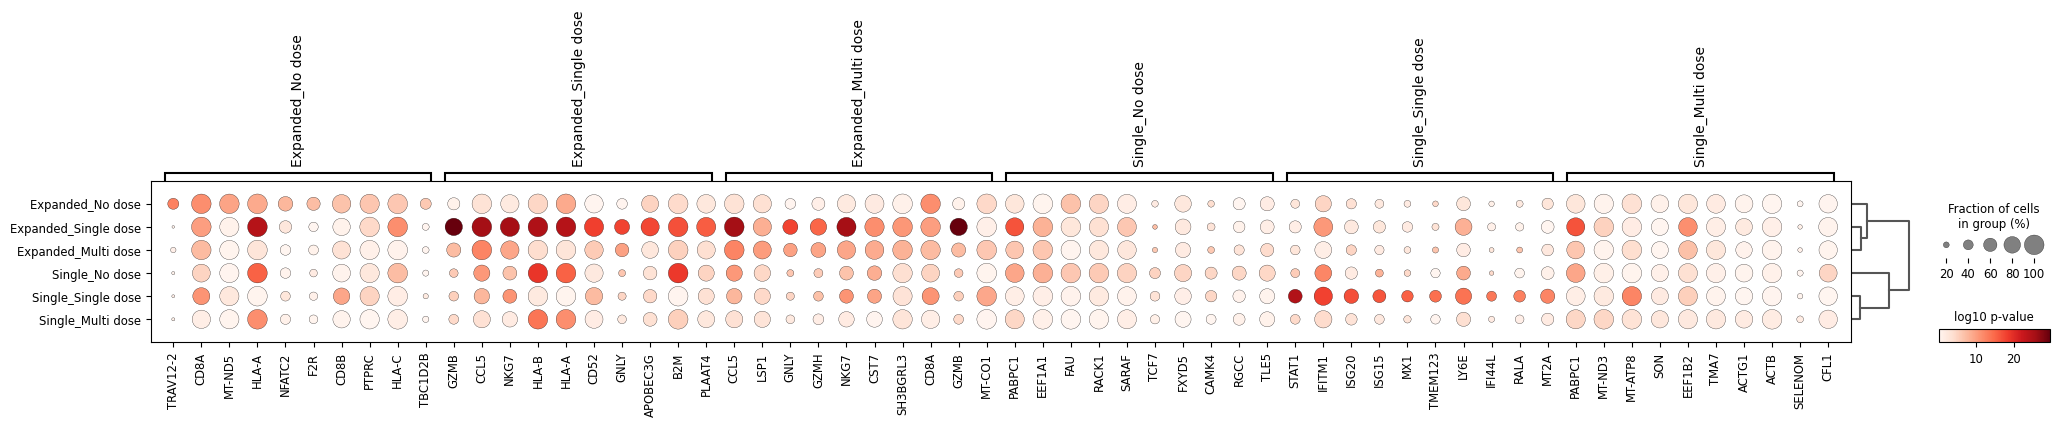

In [13]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    values_to_plot="log10_pvals",
)

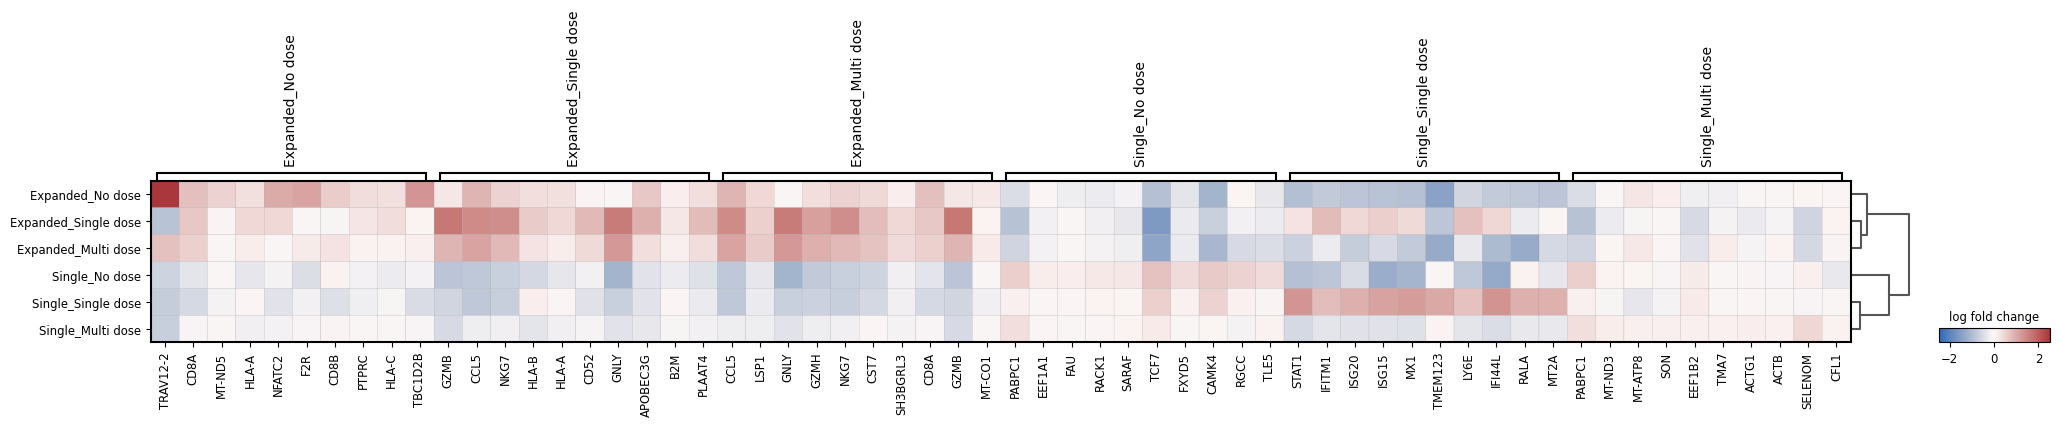

In [14]:
sc.pl.rank_genes_groups_matrixplot(
    adata,
    groupby="expand_response",
    values_to_plot="logfoldchanges",
    cmap="vlag",
    vmin=-2.5,
    vmax=2.5,
    save="top10Genes_expandTime_zScore.png"
)


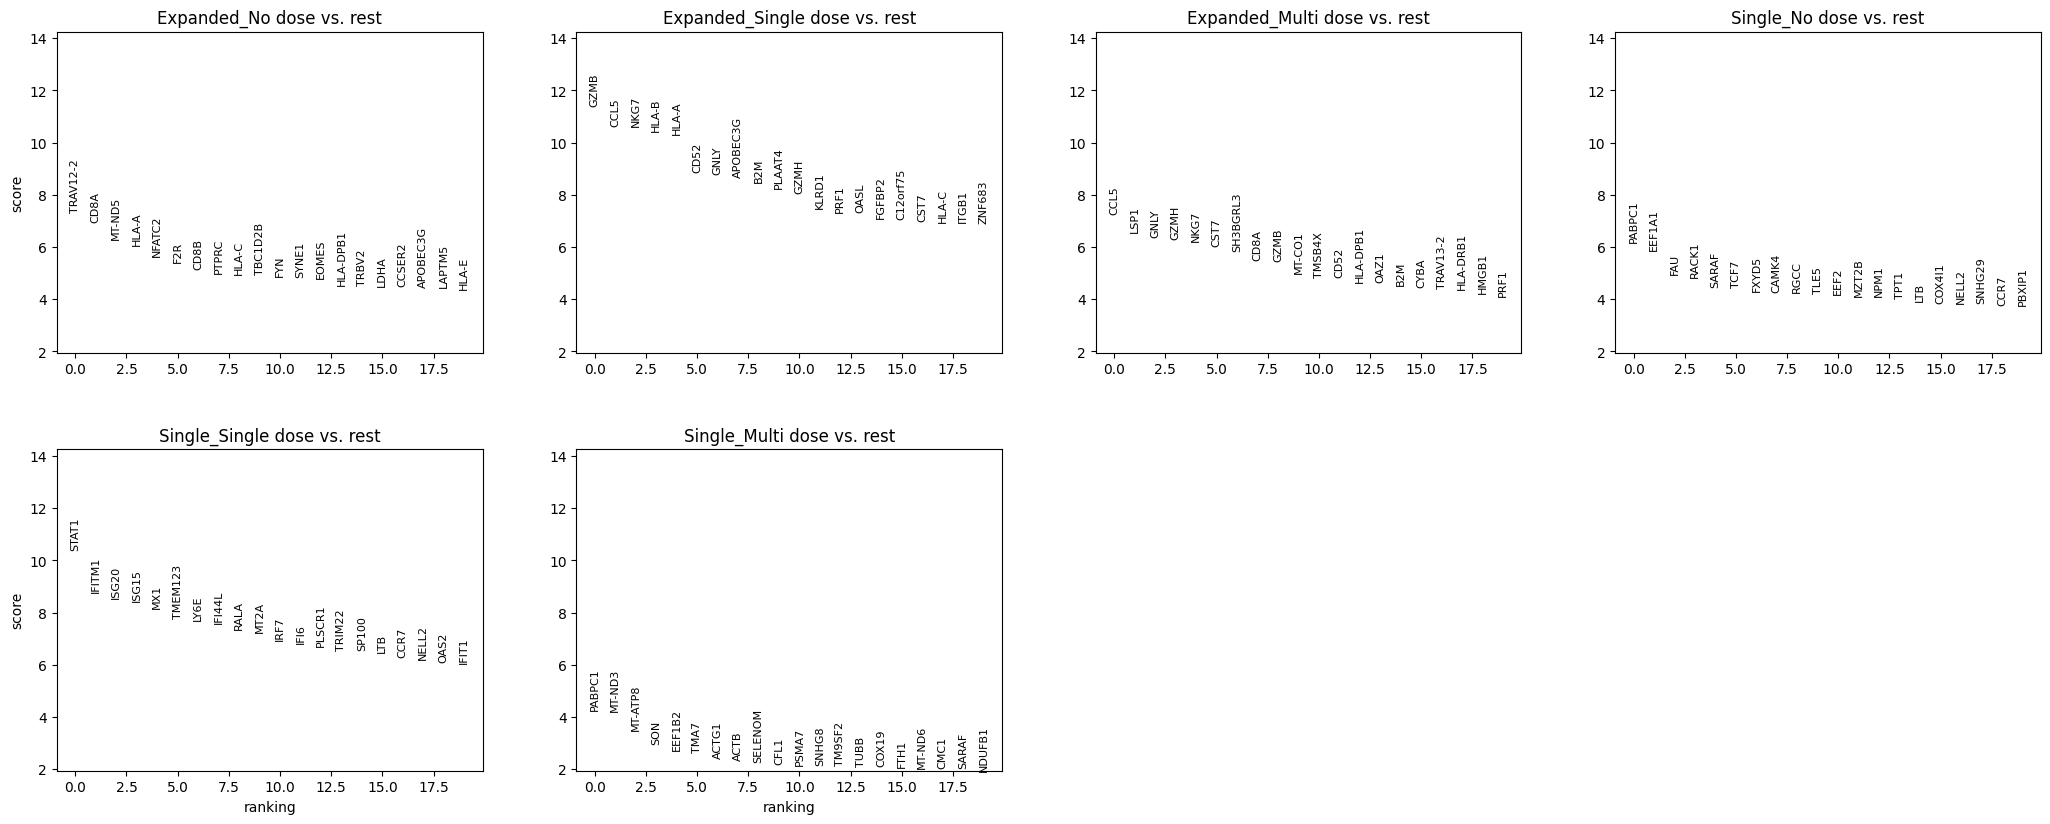

In [15]:
sc.pl.rank_genes_groups(adata)

## Violin plot, gene of interest

In [ ]:
gene_of_interest = ['GZMH','APOBEC3G','CCL5','CD8A']

In [ ]:
def plot_violin_single_gene(
    adata,
    gene_name,
    cluster=5,
    cluster_key='seurat_clusters',
    time_key='expand_response',
    layer='logcounts',
    height=12,
    width=8,
    save_path=None,
    show_legend=True
):
    """
    Simple violin plot for one gene in a single cluster, with expand_time as hue.

    Parameters:
    - adata: AnnData object
    - gene_name: str, gene to plot
    - cluster: int or str, cluster to select (default=5)
    - cluster_key: obs key for clusters
    - time_key: obs key for expand_time
    - layer: expression layer
    - height: figure height in inches
    - width: figure width in inches
    - save_path: optional path to save figure
    """

    # Check gene exists
    if gene_name not in adata.var_names:
        raise ValueError(f"Gene '{gene_name}' not found in adata.var_names")

    # Subset cells for the cluster
    mask = adata.obs[cluster_key].astype(str) == str(cluster)
    if mask.sum() == 0:
        raise ValueError(f"No cells found for cluster {cluster}")
    adata_subset = adata[mask]

    # Extract expression
    gene_idx = adata.var_names.get_loc(gene_name)
    expr_values = adata_subset.layers[layer][:, gene_idx].toarray().ravel()

    # Build dataframe
    df = pd.DataFrame({
        'expression': expr_values,
        'expand_time': adata_subset.obs[time_key].astype(str)
    })

    # Ordered timepoints
    ordered_time = [
        "Expanded_No dose",
        "Expanded_Single dose",
        "Expanded_Multi dose",
        "Single_No dose",
        "Single_Single dose",
        "Single_Multi dose"
    ]
    time_cat = CategoricalDtype(categories=ordered_time, ordered=True)
    df["expand_time"] = df["expand_time"].astype(time_cat)

    # Palette: 3 Reds + 3 Greys
    red_shades = sns.color_palette("Reds", n_colors=3)
    grey_shades = sns.color_palette("Greys", n_colors=3)
    custom_palette = red_shades + grey_shades
    palette_dict = dict(zip(ordered_time, custom_palette))

    # Plot
    plt.figure(figsize=(width, height))
    ax = sns.violinplot(
        data=df,
        x='expand_time',
        y='expression',
        order=ordered_time,
        palette=palette_dict,
        inner='box'
    )
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=16)
    plt.xlabel('')
    plt.ylabel('Expression', fontsize=18)
    plt.title(f'{gene_name} - Cluster {cluster}', fontsize=20)
     # --- Add legend manually ---
    if show_legend:
        handles = [mpatches.Patch(color=palette_dict[t], label=t) for t in ordered_time]
        ax.legend(handles=handles, title='Legend', fontsize=12, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')

    plt.show()


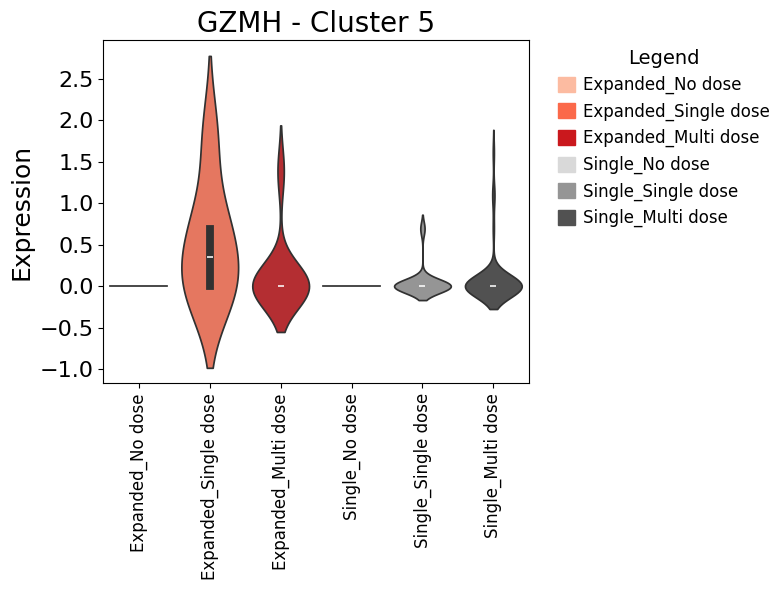

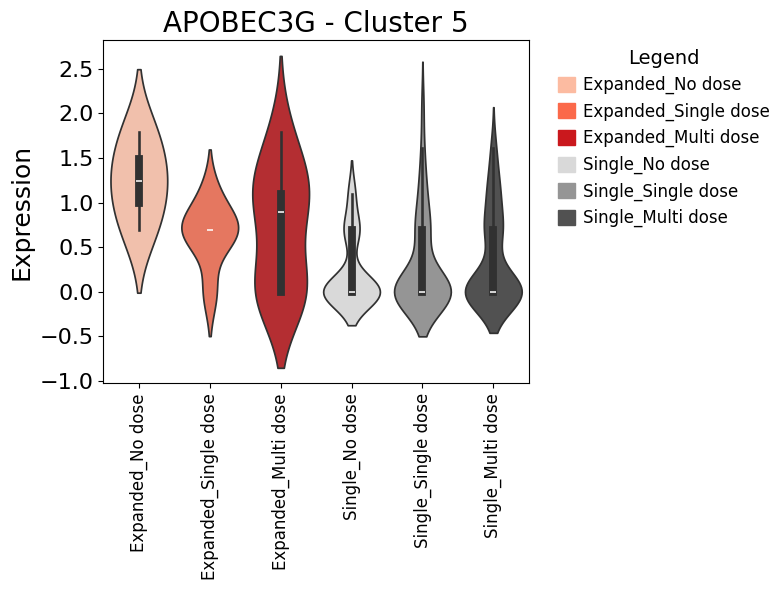

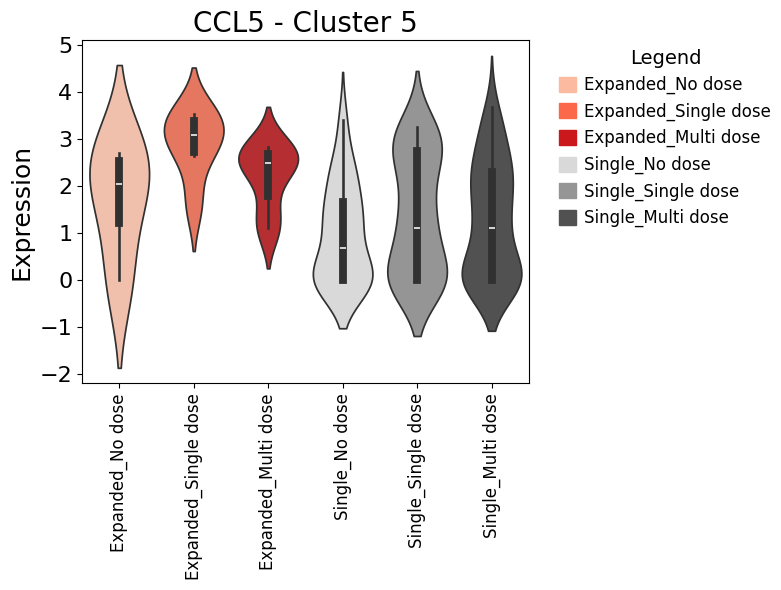

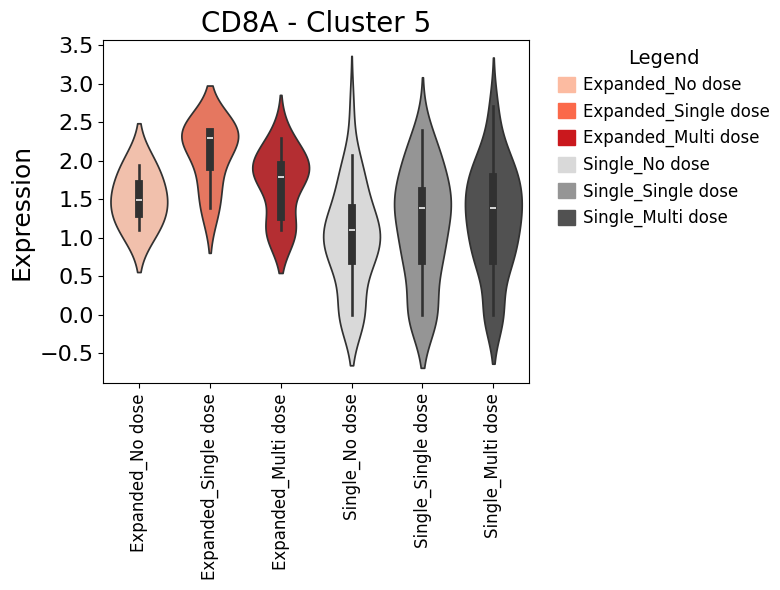

In [44]:
# You can loop over genes
for gene in gene_of_interest:
    plot_violin_single_gene(adata,
                            gene_name=gene,
                            cluster=5,
                            height=6,
                            width=8,
                            save_path=f"./figures/article/violin_{gene}.png")

## Statistics

### two ways anova

In [12]:
all_data = []
gene_of_interest=["CCL5", "APOBEC3G", "CD8A", "GZMH", "CST7"]
cluster_key='seurat_clusters'
time_key='expand_response'
layer='logcounts'

for gene_name in gene_of_interest:
    if gene_name not in adata.var_names:
        print(f"Warning: Gene '{gene_name}' not found in adata.var_names. Skipping.")
        continue

    gene_idx = adata.var_names.get_loc(gene_name)
    expr_values = adata.layers[layer][:, gene_idx].toarray().ravel()

    df = pd.DataFrame({
        'expression': expr_values,
        'cluster': adata.obs[cluster_key].astype(str),
        'expand_time': adata.obs[time_key].astype(str),
        'gene': gene_name
    })
    all_data.append(df)

# Combine all data
df_all = pd.concat(all_data, ignore_index=True)

In [25]:
df_all

,expression,cluster,expand_time,gene
0,3.218876,5,Single_Single dose,CCL5
1,2.995732,6,Single_Single dose,CCL5
2,3.637586,2,Expanded_Single dose,CCL5
3,3.433987,5,Expanded_Single dose,CCL5
4,3.828641,0,Single_Single dose,CCL5
...,...,...,...,...
10455,1.098612,4,Single_Multi dose,CST7
10456,1.791759,2,Expanded_Multi dose,CST7
10457,1.791759,0,Single_Multi dose,CST7
10458,0.000000,1,Single_Multi dose,CST7


In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

def compute_two_way_anova(df_all):
    results = []

    # Split expand_time into two factors
    df_all = df_all.copy()
    df_all['expansion'] = df_all['expand_time'].str.extract(r'^(Expanded|Single)')
    df_all['dose'] = df_all['expand_time'].str.extract(r'(No dose|Single dose|Multi dose)')

    for gene in df_all['gene'].unique():
        for cluster in df_all['cluster'].unique():
            sub_df = df_all[(df_all['gene'] == gene) & (df_all['cluster'] == cluster)]

            if sub_df['expansion'].nunique() < 2 or sub_df['dose'].nunique() < 2:
                continue  # Not enough variability

            try:
                model = ols("expression ~ C(expansion) * C(dose)", data=sub_df).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
                results.append({
                    "gene": gene,
                    "cluster": cluster,
                    "expansion_pval": anova_table.loc["C(expansion)", "PR(>F)"],
                    "dose_pval": anova_table.loc["C(dose)", "PR(>F)"],
                    "interaction_pval": anova_table.loc["C(expansion):C(dose)", "PR(>F)"]
                })
            except Exception as e:
                results.append({
                    "gene": gene,
                    "cluster": cluster,
                    "expansion_pval": None,
                    "dose_pval": None,
                    "interaction_pval": None
                })

    return pd.DataFrame(results)


In [15]:
results_anova_tw = compute_two_way_anova(df_all)

/home/mbrochut@ad.unil.ch/miniconda3/envs/single_cell/lib/python3.12/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/home/mbrochut@ad.unil.ch/miniconda3/envs/single_cell/lib/python3.12/site-packages/statsmodels/base/model.py:1925: RuntimeWarning: invalid value encountered in divide
  F /= J
/home/mbrochut@ad.unil.ch/miniconda3/envs/single_cell/lib/python3.12/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/home/mbrochut@ad.unil.ch/miniconda3/envs/single_cell/lib/python3.12/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 0
  warnings.warn('c

In [27]:
results_anova_tw.sort_values('expansion_pval').to_excel("./results/two_way_ANOVA.xlsx")

### One way anova

In [16]:
from scipy.stats import f_oneway

def compute_anova_per_gene_cluster(df_all):
    results = []

    for gene in df_all['gene'].unique():
        for cluster in df_all['cluster'].unique():
            sub_df = df_all[(df_all['gene'] == gene) & (df_all['cluster'] == cluster)]
            
            # Group expression values by expand_time
            groups = [group["expression"].values for name, group in sub_df.groupby("expand_time")]

            # Only test if we have at least 2 groups with >1 value
            if sum([len(g) > 1 for g in groups]) >= 2:
                try:
                    stat, pval = f_oneway(*groups)
                except Exception as e:
                    pval = None
            else:
                pval = None

            results.append({
                "gene": gene,
                "cluster": cluster,
                "anova_pval": pval
            })

    return pd.DataFrame(results)


In [17]:
one_way = compute_anova_per_gene_cluster(df_all)

/tmp/ipykernel_2050575/314405917.py:16: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  stat, pval = f_oneway(*groups)
/tmp/ipykernel_2050575/314405917.py:16: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  stat, pval = f_oneway(*groups)


In [26]:
one_way.sort_values('anova_pval').to_excel("./results/one_way_ANOVA.xlsx")

In [146]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

def run_tukey_posthoc(df_all):
    results = []

    for gene in df_all['gene'].unique():
        for cluster in df_all['cluster'].unique():
            sub_df = df_all[(df_all['gene'] == gene) & (df_all['cluster'] == cluster)]

            if sub_df['expand_time'].nunique() < 2:
                continue

            try:
                tukey = pairwise_tukeyhsd(
                    endog=sub_df['expression'],
                    groups=sub_df['expand_time'],
                    alpha=0.05
                )
                
                # Use .data to get table as a list of rows (including header row)
                tukey_data = tukey.summary().data[1:]  # skip header
                columns = ['group1', 'group2', 'meandiff', 'p-adj', 'lower', 'upper', 'reject']
                tukey_df = pd.DataFrame(tukey_data, columns=columns)
                
                # Convert numeric columns
                tukey_df[['meandiff', 'p-adj', 'lower', 'upper']] = tukey_df[['meandiff', 'p-adj', 'lower', 'upper']].astype(float)
                tukey_df['reject'] = tukey_df['reject'].astype(bool)

                # Add gene and cluster
                tukey_df['gene'] = gene
                tukey_df['cluster'] = cluster

                results.append(tukey_df)
            except Exception as e:
                print(f"Skipped {gene}-{cluster} due to error: {e}")
                continue

    # Combine all results into a single DataFrame
    return pd.concat(results, ignore_index=True)


In [147]:
tukey_res = run_tukey_posthoc(df_all)

/home/mbrochut@ad.unil.ch/miniconda3/envs/single_cell/lib/python3.12/site-packages/statsmodels/sandbox/stats/multicomp.py:1300: RuntimeWarning: invalid value encountered in divide
  st_range = np.abs(meandiffs) / std_pairs #studentized range statistic
/home/mbrochut@ad.unil.ch/miniconda3/envs/single_cell/lib/python3.12/site-packages/statsmodels/sandbox/stats/multicomp.py:1300: RuntimeWarning: invalid value encountered in divide
  st_range = np.abs(meandiffs) / std_pairs #studentized range statistic


In [152]:
tuckey_cluster_5 = tukey_res[tukey_res['cluster']=="5"]

In [153]:
tuckey_cluster_5.to_excel("./results/tuckey_postHocTest_cluster5.xlsx")